---
# Import Library

---

In [43]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

---
# Data Loading

---

In [3]:
# Since the data is located on directory '../data/cleaned' from DE part:
df = pd.read_csv('../data/cleaned/modelling_df_v0_1.csv', index_col=0) # use index column
backup_df = df.copy() # for backup of changes in original df

# Check the summary with info method()
df.info()

pd.set_option('display.max_columns', None) # to see all columns
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 117784 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117784 non-null  object 
 1   customer_id                    117784 non-null  object 
 2   order_status                   117784 non-null  object 
 3   order_purchase_timestamp       117784 non-null  object 
 4   order_approved_at              117608 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117784 non-null  object 
 8   order_item_id                  117597 non-null  float64
 9   product_id                     117597 non-null  object 
 10  shipping_limit_date            117597 non-null  object 
 11  price                          117597 non-null  float64
 12  freight_value                  1175

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,060cb19345d90064d1015407193c233d,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,a1804276d9941ac0733cfd409f5206eb,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,4520766ec412348b8d4caa5e8a18c464,2017-05-22 13:22:11,59.99,15.17

#TODO hasil bahasan sama bang kevin, jadinya 2 df di bagian EDA ini, kedua2nya dilakuin

In [4]:
# Aggregated data also located in same directory '../data/cleaned' from DE part:
df_agg = pd.read_csv('../data/cleaned/order_agg_modeling_v0_1.csv', index_col=0) # use index column
backup_df_agg = df_agg.copy() # for backup of changes in original df_agg

# Check the summary with info method()
df_agg.info()

df_agg.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 98832 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98832 non-null  object 
 1   customer_id                    98832 non-null  object 
 2   order_status                   98832 non-null  object 
 3   order_purchase_timestamp       98832 non-null  object 
 4   order_approved_at              98672 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  98832 non-null  object 
 8   total_items                    98660 non-null  float64
 9   total_order_value              98660 non-null  float64
 10  total_freight                  98660 non-null  float64
 11  avg_item_price                 98660 non-null  float64
 12  payment_type                   98831 non-null  obje

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,29.99,voucher,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,118.70,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,147.90,27.36,147.90,credit_card,175.26,6.0,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,49.90,16.05,49.90,credit_card,65.95,1.0,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,59.99,15.17,59.99,credit_card,75.16,3.0,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,19.90,16.05,19.90,boleto,35.95,1.0,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1.0,149.99,19.77,149.99,credit_card,169.76,1.0,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,0


In [5]:
df.customer_id.value_counts()

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
63b964e79dee32a3587651701a2b8dbf    24
                                    ..
6f2cf56878f7f82151b0ad02590192c0     1
3803547f820b1e10b7ad9c7985f06753     1
a046c690e0564ffde0ce611b5eee2c30     1
ad312389a098ceff46ce92c4595c06d0     1
f00bb12620b7b232233cace1b229db18     1
Name: count, Length: 98832, dtype: int64

Note that there are some customers with multiple orders on the dataset. Perhaps there may be multiple cancelled order for each customer that later we will observed.

---
# Data Cleaning
---

---
# Exploratory Data Analysis
---

All of the questions:
#TODO ini nanti crosscheck di discord lagi, siapa tau ada yang diedit, terutama nomor 3 itu baru dari bahasan ama bang kevin -- harapannya hasil dari nomor 3 ga bagus, maka nomor 4 dst cukup `df` aja, gaperlu 

1. What is the overall cancellation rate in the historical dataset?
2. What is the distribution of customer level cancellation rate? #TODO sepertinya malah jadi banyak cancellation paling tinggi dari setiap customer
3. How is the cancellation rate for each product? #TODO ini yang baru -- jadi per `product_id` bang
4. Which customer segments are most likely to cancel their orders based on transaction history
5. When do order cancellations most frequently occur?
6. Where do order cancellation most frequently occur, based on customer location?
7. Which features show the strongest relationship with order cancellations?
8. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?

---
### 1. Overall cancellation rate
---


In [6]:
# overall cancel rate for DF_Modeling
cancel_rate_df= (
    df['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_df

is_canceled
Not Canceled    0.993675
Canceled        0.006325
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

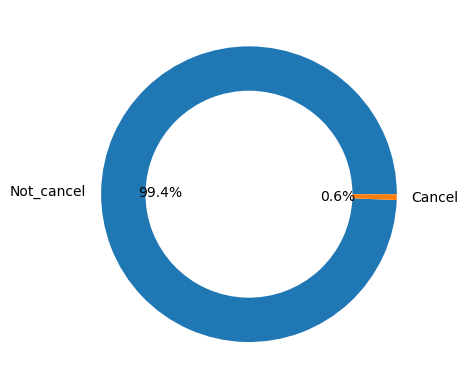

In [7]:
# Pie chart for DF_Modeling
plt.pie(
    cancel_rate_df.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.1f%%",
    explode=[0,0],
    wedgeprops={'width':0.3}
)
plt.show


This distribution from dataset `modelling_df` shows that most orders are not canceled, with a very low cancellation rate of around 0.63% of total transactions. This indicates that cancellations are not a systemic issue, but rather a relatively rare occurrence likely triggered by certain conditions or factors, such as payment methods, specific customer behavior, or particular transaction situations. That indicates our data is imbalanced

In [8]:
# overall cancel rate for DF_Agg
cancel_rate_agg= (
    df_agg['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_agg

is_canceled
Not Canceled    0.993676
Canceled        0.006324
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

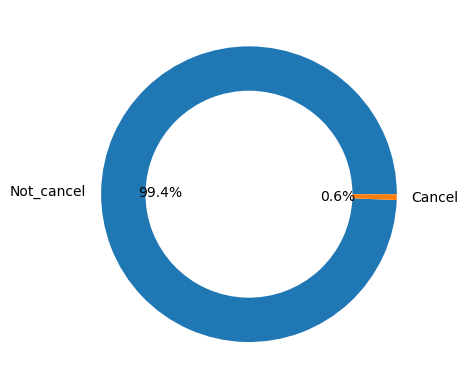

In [9]:
# Pie chart for DF_Agg
plt.pie(
    cancel_rate_df.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.1f%%",
    explode=[0,0],
    wedgeprops={'width':0.3}
)
plt.show


This distribution from dataset `order_agg_modeling` shows that most orders are not canceled, with a very low cancellation rate of around 0.63% of total transactions. This indicates that cancellations are not a systemic issue, but rather a relatively rare occurrence likely triggered by certain conditions or factors, such as payment methods, specific customer behavior, or particular transaction situations. That indicates our data is imbalanced

---
### 2. What is the distribution of customer level cancellation rate?
---

In [ ]:
# Group data by customer_id to analyze cancellations by customer on Dataset modelling_df
rate_cancel_percustomer= df.groupby("customer_id")["is_canceled"].sum()
top_5 = rate_cancel_percustomer.sort_values(ascending=False).head(5)

In [ ]:
# show the top 5 customer cancellations
top_5

customer_id
33b3ac58c257992bb9f0dff11643b8d0    9
20153d17ff713721abd8b4c082d5e4d5    8
616833eaef04d25b67207119cd6936dc    6
d9335c099e6943d88ac5f8a7cb418b66    6
c52f8523a6448c43354e5ca966f61e4c    6
Name: is_canceled, dtype: int64

<Axes: xlabel='is_canceled', ylabel='customer_id'>

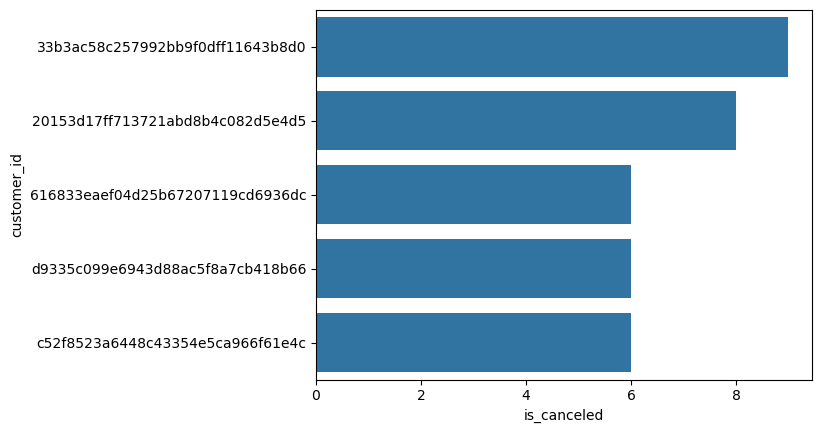

In [ ]:
# Visualize the top_5 customer cancellations
sns.barplot(top_5,orient='h')

Based on dataset `modelling_df`, show that order cancellations are not evenly distributed across all customers, but are concentrated among a small number of customers with a high frequency of cancellations. Customers with the highest number of cancellations reached 9 times, while other customers were in the range of 6–8 cancellations, indicating the presence of a recurring behavior pattern (repeat cancellation behavior).

In [ ]:
# Group data by customer_id to analyze cancellations by customer on Dataset order_agg_Modelling
rate_cancel_percustomer_agg= df_agg.groupby("customer_id")["is_canceled"].sum()
top_5_agg = rate_cancel_percustomer_agg.sort_values(ascending=False).head(5)

In [48]:
# show the top 5 customer cancellations
top_5_agg

customer_id
19f1fc491b7b350f93bb538f0cd48912    1
7a8a02e54cf3472df427e927f8b9c046    1
4c2ec60c29d10c34bd49cb88aa85cfc4    1
5b50a17129a0fbaa9501a3ff84bca338    1
24455809d8e25059274e820cc202b50a    1
Name: is_canceled, dtype: int64

<Axes: xlabel='is_canceled', ylabel='customer_id'>

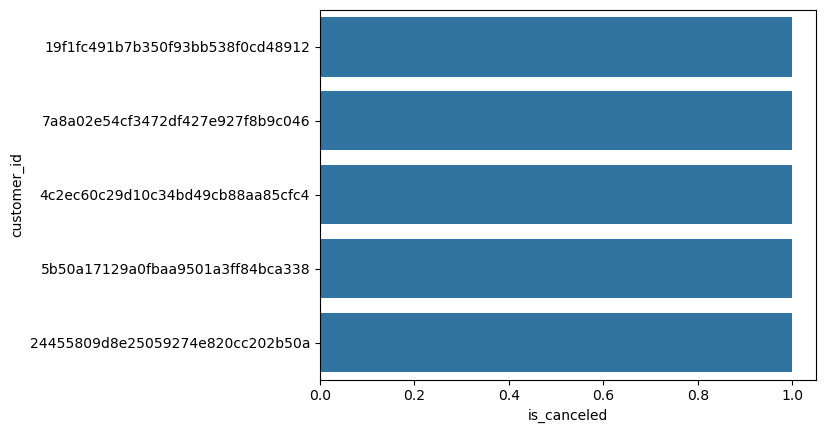

In [ ]:
# Visualize the top_5 customer cancellations
sns.barplot(top_5_agg,orient='h')

Based on dataset `order_agg_modelling` show that most customers only cancel once, which indicates that cancellations are generally incidental or situational, not habitual. This pattern differs from the small group of customers who have repeated cancellations, so it can be concluded that the high risk of cancellation is more concentrated among a minority of customers, rather than the majority of the customer base.

---
### 3. How is the cancellation rate for each product?
---

In [ ]:
# Group data by product_id to analyze cancellations at product# Group data by product_id to analyze cancellations at product
product_cancel_rate = df.groupby('product_id')['is_canceled'].sum().sort_values(ascending=False)

product_cancel_rate.head(10)

product_id
d274714b715480aa8ca7fca7d2524233    9
5c3eaf54e8ee5d5378765ff16df7640b    6
8397dc503d1a0c2ac7422701884de5a6    6
1c42962612d557f85753b24c2b97070f    5
7d4f932dd4fa16256c20de073329eacc    5
75f3ef6a5cb0f2d5aeef15925f0ccf69    5
3ea32f63a6aaf8d467e543dedf434ee7    5
66b1f09e746c05761bcaccf6339bde8d    5
99b4367cf2228c8a86922a0649bee6b8    5
ed08ea04c92f5f434c2362f7310fb328    5
Name: is_canceled, dtype: int64

In [ ]:
# Select the top 10 products with the highest number of canceled orders
top_10_products = product_cancel_rate.head(10)

<Axes: xlabel='is_canceled', ylabel='product_id'>

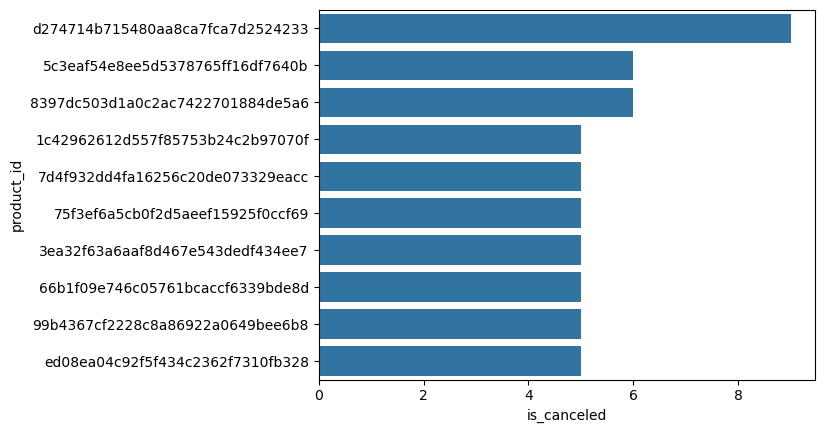

In [ ]:
# Visualize the top 10 product with the highest canceled orders
sns.barplot(top_10_products,orient='h')

The results show that order cancellations are not evenly distributed across all products, but are concentrated on certain product_ids. The products with the highest cancellations only reached 9 cases, while other products ranged from 5–6 cancellations, indicating that no single product dominates in causing cancellations, but rather cancellations are thinly spread across many products.

---
### 4. Which customer segments are most likely to cancel their orders based on transaction history
---

In [ ]:
# Group data by payment_type and calculate the total number of cancelled orders for each payment method

cancel_by_payment = df_agg.groupby('payment_type')['is_canceled'].sum().sort_values(ascending=False)
cancel_by_payment 

payment_type
credit_card    440
boleto          95
voucher         80
debit_card       7
not_defined      3
Name: is_canceled, dtype: int64

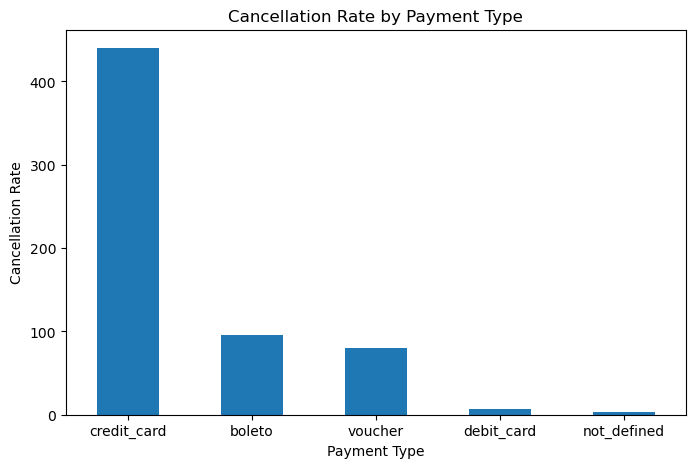

In [32]:
# Make a visuzaliation of cancel by payment

plt.figure(figsize=(8,5))

cancel_by_payment.plot(kind='bar')
plt.ylabel('Cancellation Rate')
plt.xlabel('Payment Type')
plt.title('Cancellation Rate by Payment Type')
plt.xticks(rotation=360)
plt.show()

The `credit card` payment method shows the highest number of cancellations, likely due to the large transaction volume as well as the payment flexibility that makes it easier for customers to cancel orders. Meanwhile, `boleto` and `vouchers` also have relatively high cancellations, whereas debit cards and not_defined methods show much lower cancellation risk due to their more limited use and tendency to be final.

---
### 5. When do order cancellations most frequently occur?
---

In [ ]:
# Convert the order purchase timestamp column to datetime format
df_agg['order_purchase_timestamp'] = pd.to_datetime(df_agg["order_purchase_timestamp"])

# declarate cancelled orders on a weekly basis
cancel_date_agg = df_agg.set_index("order_purchase_timestamp")["is_canceled"].resample("W").sum()
cancel_date_agg

order_purchase_timestamp
2016-09-04    0
2016-09-11    1
2016-09-18    1
2016-09-25    0
2016-10-02    1
             ..
2018-09-23    2
2018-09-30    3
2018-10-07    2
2018-10-14    0
2018-10-21    2
Freq: W-SUN, Name: is_canceled, Length: 112, dtype: int64

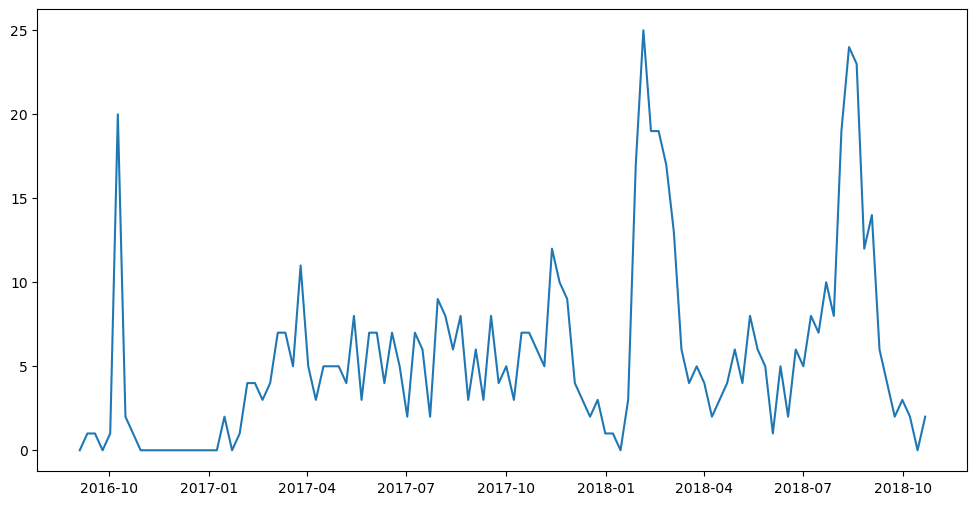

In [ ]:
# Visualize plot of cancel_date_agg

plt.figure(figsize=(12,6))
plt.plot(cancel_date_agg.index, cancel_date_agg.values)
plt.show()

Based on the cancellation pattern over time, there is no clear seasonal or temporal trend that consistently drives order cancellations. The cancellation activity appears to fluctuate irregularly without forming a predictable pattern. This suggests that order cancellations are largely situational and spontaneous, likely influenced by individual buyer decisions, payment issues, or other external factors, rather than being planned or driven by specific time periods.

---
### 6. Where do order cancellation most frequently occur, based on customer location?
---

In [ ]:
# Group data by customer city and count the total
cancel_by_location = df_agg.groupby('customer_city')['is_canceled'].sum().sort_values(ascending=False)

# Select the top 10 cities
top_10_city = cancel_by_location.head(10)
top_10_city

customer_city
sao paulo                140
rio de janeiro            48
belo horizonte            17
guarulhos                 13
campinas                  11
curitiba                  10
osasco                     8
sao bernardo do campo      8
brasilia                   7
sorocaba                   7
Name: is_canceled, dtype: int64

The results show that Sao Paulo has the highest number of cancelled orders by a wide margin, followed by Rio de Janeiro and Belo Horizonte. This pattern likely reflects the higher transaction volume in major metropolitan areas rather than a higher inherent tendency to cancel orders.

<Axes: xlabel='is_canceled', ylabel='customer_city'>

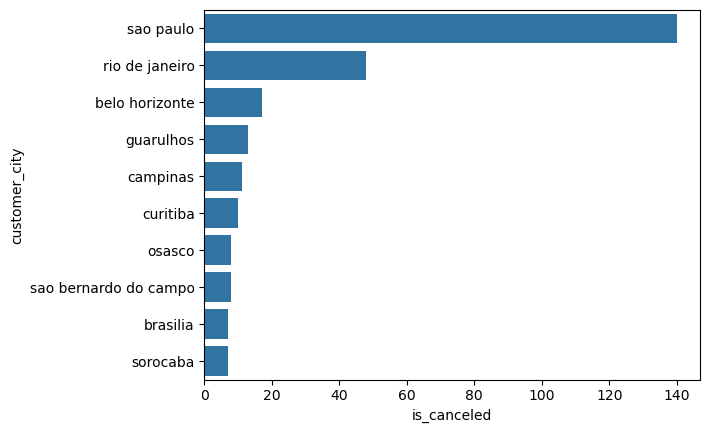

In [ ]:
# Make a visuzaliation of cancel by location
sns.barplot(top_10_city,orient='h')

---
### 7.Which features show the strongest relationship with order cancellations?
---

In [ ]:
# Select only numerical columns to compute the Pearson correlation matrix and extract correlations with is_canceled
numeric_df_agg = df_agg.select_dtypes(include='number').dropna()
numeric_df_agg.corr()['is_canceled'].drop('is_canceled').sort_values(ascending=False)

total_order_value           0.022395
total_payment_value         0.021495
avg_item_price              0.020366
total_items                 0.004326
max_installments            0.004076
total_freight               0.000883
customer_zip_code_prefix   -0.018114
Name: is_canceled, dtype: float64

The correlation results indicate that transaction value related features such as `total order value`, `total payment value`, and `average item price` show the strongest positive relationships with order cancellations, although the overall correlation magnitudes are relatively small. This is expected given the binary nature of the cancellation variable.

---
### 8.For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?
---

In [ ]:
# List of top numerical features to be tested
features = ['total_order_value', 'total_payment_value', 'avg_item_price']

# Loop feature to perform statistical testing
for col in features:
    cancelled = df_agg[df_agg['is_canceled'] == 1][col]
    not_cancelled = df_agg[df_agg['is_canceled'] == 0][col]
    
     # Perform t-test
    t_stat, p_value = ttest_ind(cancelled, not_cancelled, equal_var=False, nan_policy='omit')
    
    # Print the t-statistic and p-value
    print(f"{col}: t-stat = {t_stat:.3f}, p-value = {p_value:.5f}")

total_order_value: t-stat = 3.737, p-value = 0.00021
total_payment_value: t-stat = 4.163, p-value = 0.00004
avg_item_price: t-stat = 3.691, p-value = 0.00025


The t-test results show that all three top transaction value related features `total order value`, `total payment value`, and `average item price`,exhibit statistically significant differences between cancelled and non-cancelled orders (p < 0.001).